In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [18]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

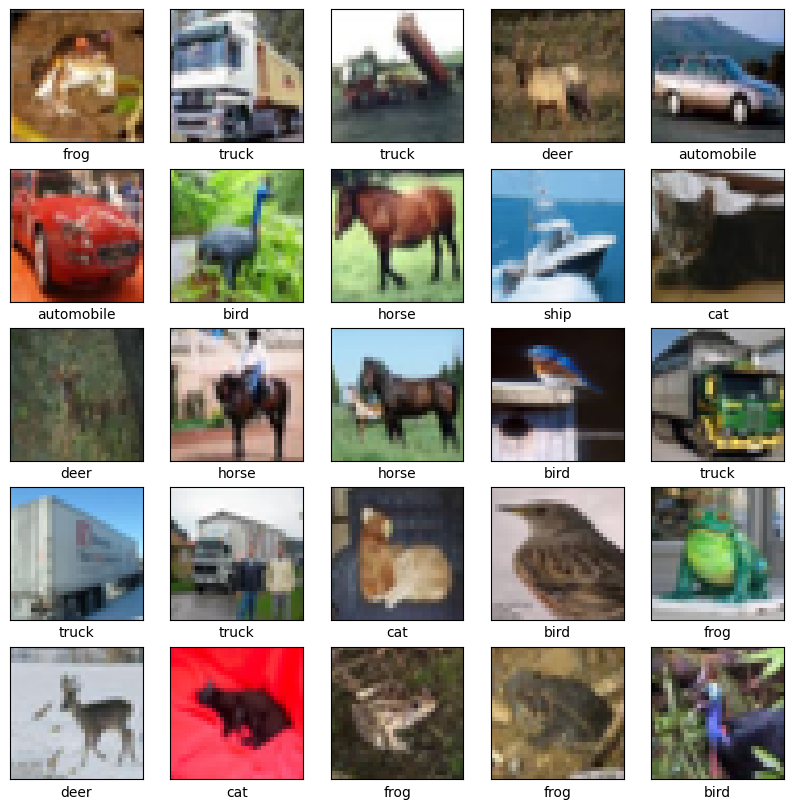

In [19]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [20]:
model = models.Sequential()

# This new Input layer fixes the red UserWarning in your screenshot!
model.add(layers.Input(shape=(32, 32, 3)))

# Layer 1
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Layer 4 (Your new addition!)
# We increase the filters to 128 to help it learn more complex patterns
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,176 (508.50 KB)

 Trainable params: 130,176 (508.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,658 (639.29 KB)

 Trainable params: 163,658 (639.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2032 - loss: 2.1435 - val_accuracy: 0.2618 - val_loss: 1.9985
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3357 - loss: 1.8316 - val_accuracy: 0.3830 - val_loss: 1.7240
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4245 - loss: 1.5825 - val_accuracy: 0.4255 - val_loss: 1.5647
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4825 - loss: 1.4357 - val_accuracy: 0.5086 - val_loss: 1.3781
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5224 - loss: 1.3349 - val_accuracy: 0.5210 - val_loss: 1.3285
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5544 - loss: 1.2547 - val_accuracy: 0.5388 - val_loss: 1.3168
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5812 - loss: 1.1850 - val_accuracy: 0.5503 - val_loss: 1.3261
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6036 - loss: 1

313/313 - 1s - 3ms/step - accuracy: 0.6109 - loss: 1.0964


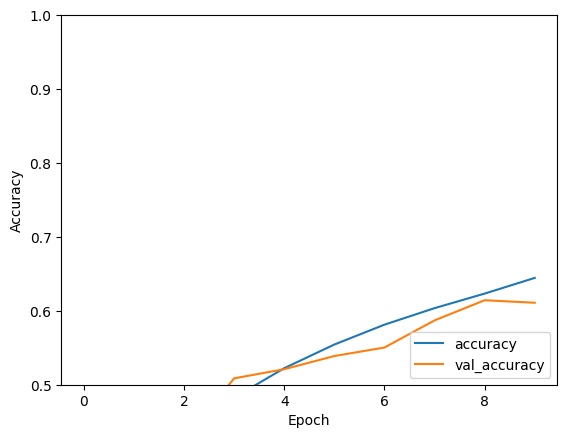

In [23]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [24]:
print(test_acc)

0.6108999848365784


In [25]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6160 - loss: 1.0943 - val_accuracy: 0.6104 - val_loss: 1.0867
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6689 - loss: 0.9431 - val_accuracy: 0.6616 - val_loss: 0.9699
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7069 - loss: 0.8310 - val_accuracy: 0.6653 - val_loss: 0.9617
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7411 - loss: 0.7372 - val_accuracy: 0.6884 - val_loss: 0.9136
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7718 - loss: 0.6506 - val_accuracy: 0.6990 - val_loss: 0.8860
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7937 - loss: 0.5852 - val_accuracy: 0.7003 - val_loss: 0.9170
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8180 - loss: 0.5169 - val_accuracy: 0.7068 - val_loss: 0.9391
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8380 - loss: 0

313/313 - 1s - 3ms/step - accuracy: 0.6920 - loss: 1.1614


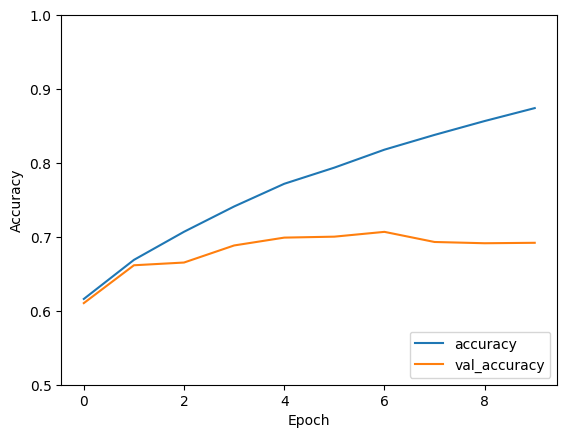

In [26]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [27]:
print(test_acc)

0.6919999718666077


In [28]:
# save model
model.save('final_model.keras') #previously saved as 'final_model.h5", a legacy

--- Starting Predictions ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

File: airplane.jpg --> AI Prediction: airplane (100.00%)


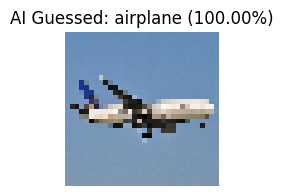

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

File: bird1.jpg --> AI Prediction: bird (89.29%)


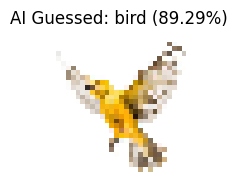

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

File: ship.jpg --> AI Prediction: ship (100.00%)


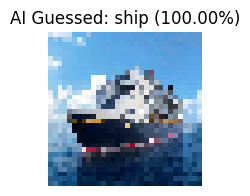

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

File: deer_capture_0.png --> AI Prediction: deer (82.88%)


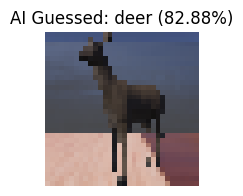

In [29]:
# make a prediction for new images
import tensorflow as tf
from tensorflow.keras import preprocessing
from tensorflow.keras import models
import numpy as np
import matplotlib.pyplot as plt # We added this to draw the images!

# Re-define class names just to be safe
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def load_image(filename):
	# load the image
	img = preprocessing.image.load_img(filename, target_size=(32, 32))
	# convert to array
	img = preprocessing.image.img_to_array(img)
	# reshape into a single sample with 3 channels
	img = img.reshape(1, 32, 32, 3)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img

def run_example():
	# Load the model
	model = models.load_model('final_model.keras')

	# Your exact file names
	my_images = ['airplane.jpg', 'bird1.jpg', 'ship.jpg', 'deer_capture_0.png']

	print("--- Starting Predictions ---")
	for img_name in my_images:
		try:
			img = load_image(img_name)
			pred_list = model.predict(img)

			# --- NEW PERCENTAGE MATH ---
			# 1. Convert the raw output numbers into probability percentages
			probabilities = tf.nn.softmax(pred_list[0])

			# 2. Find the index of the highest percentage
			result = np.argmax(probabilities)

			# 3. Get the actual class name and the highest percentage value (multiplied by 100)
			prediction = class_names[result]
			confidence = probabilities[result] * 100
			# ---------------------------

			# Updated print statement to show the percentage rounded to 2 decimal places
			print(f"\nFile: {img_name} --> AI Prediction: {prediction} ({confidence:.2f}%)")

			# Draw the 32x32 image on the screen
			plt.figure(figsize=(2,2))
			plt.imshow(img[0])
			# Updated title to show the percentage on the graph
			plt.title(f"AI Guessed: {prediction} ({confidence:.2f}%)")
			plt.axis('off')
			plt.show()

		except FileNotFoundError:
			print(f"Error: Could not find '{img_name}'. Make sure you uploaded it to Colab!")

# run the example
run_example()